# 03 — Regime-Conditioned Risk

This notebook asks whether the detected regimes correspond to materially different risk profiles.

The central research question is:

> Do the estimated regimes identify different covariance, correlation, drawdown, and tail-risk environments?

This notebook does not optimize a strategy. It validates whether regime awareness is meaningful from a risk-estimation perspective.

Expected local outputs:

- `data/processed/regime_risk_summary.csv`
- `data/processed/regime_correlation_long.csv`
- `data/processed/regime_covariance_long.csv`
- `reports/figures/03_regime_risk_bars.png`
- `reports/figures/03_regime_return_distributions.png`
- `reports/figures/03_regime_correlation_heatmaps.png`

In [ ]:
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
regimes = pd.read_csv(DATA_DIR / "regime_labels.csv", index_col=0, parse_dates=True)["regime"]

aligned = returns.join(regimes.rename("regime"), how="inner").dropna()

returns_aligned = aligned[returns.columns]
regimes_aligned = aligned["regime"].astype(int)

print("Aligned return panel:", returns_aligned.shape)
display(regimes_aligned.value_counts().sort_index().rename("n_obs"))

Aligned return panel: (4788, 7)


regime
1      45
2    4743
Name: n_obs, dtype: int64

## 2. Define a simple diagnostic portfolio

For risk diagnostics, we start with an equal-weight portfolio.

This is deliberately simple. The purpose is to understand the regime-risk relationship before introducing optimization or dynamic allocation.

In [4]:
equal_weight_portfolio_returns = returns_aligned.mean(axis=1).rename("equal_weight_portfolio")

display(equal_weight_portfolio_returns.describe())

count   4,788.0000
mean        0.0002
std         0.0036
min        -0.0236
25%        -0.0017
50%         0.0003
75%         0.0022
max         0.0250
Name: equal_weight_portfolio, dtype: float64

## 3. Compute regime-conditioned risk summary

The summary reports, by regime:

- number of observations,
- annualized return,
- annualized volatility,
- Sharpe ratio with zero risk-free rate,
- historical 5% CVaR,
- maximum drawdown,
- average pairwise correlation.

The key metrics for this project are volatility, CVaR, drawdown, and correlation. Return estimates are shown for completeness but should not be overinterpreted.

In [5]:
risk_summary = regime_risk_summary(
    returns=returns_aligned,
    regimes=regimes_aligned,
    portfolio_returns=equal_weight_portfolio_returns,
    annualization=252,
    cvar_alpha=0.05,
)

display(risk_summary)

,regime,n_obs,ann_return,ann_vol,sharpe_0rf,cvar_5pct,max_drawdown,avg_pairwise_corr
0,1,45,0.0455,0.0546,0.8332,0.0082,-0.0169,0.1569
1,2,4743,0.0440,0.0578,0.7611,0.0085,-0.1425,0.0423


## 4. Estimate covariance and correlation by regime

Regime-conditioned covariance and correlation matrices help answer whether diversification behaves differently across stress states.

In a stress-control project, correlation instability is often as important as volatility itself because diversification can break down exactly when it is most needed.

In [6]:
covariances = covariance_by_regime(returns_aligned, regimes_aligned, annualization=252)
correlations = correlation_by_regime(returns_aligned, regimes_aligned)

for regime, corr in correlations.items():
    print(f"Regime {regime} correlation matrix")
    display(corr)

Regime 1 correlation matrix


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
DBC,1.0000,0.4084,-0.1507,-0.0291,0.0471,-0.0690,-0.0193
GLD,0.4084,1.0000,0.1539,0.0995,0.4244,0.2928,0.0010
IEF,-0.1507,0.1539,1.0000,0.8856,-0.1432,0.9469,-0.1124
SHY,-0.0291,0.0995,0.8856,1.0000,-0.3161,0.8163,-0.0072
SPY,0.0471,0.4244,-0.1432,-0.3161,1.0000,-0.0484,0.2359
TLT,-0.0690,0.2928,0.9469,0.8163,-0.0484,1.0000,-0.1221
UUP,-0.0193,0.0010,-0.1124,-0.0072,0.2359,-0.1221,1.0000


Regime 2 correlation matrix


,DBC,GLD,IEF,SHY,SPY,TLT,UUP
DBC,1.0000,0.3432,-0.2045,-0.1377,0.4077,-0.2339,-0.2954
GLD,0.3432,1.0000,0.2228,0.2274,0.0552,0.1684,-0.4216
IEF,-0.2045,0.2228,1.0000,0.7601,-0.3001,0.9108,-0.1547
SHY,-0.1377,0.2274,0.7601,1.0000,-0.2318,0.5656,-0.2166
SPY,0.4077,0.0552,-0.3001,-0.2318,1.0000,-0.3116,-0.1935
TLT,-0.2339,0.1684,0.9108,0.5656,-0.3116,1.0000,-0.0711
UUP,-0.2954,-0.4216,-0.1547,-0.2166,-0.1935,-0.0711,1.0000


## 5. Visual diagnostic — risk metrics by regime

This plot focuses on risk, not alpha.

The key question is whether high-stress regimes exhibit higher volatility, higher CVaR, deeper drawdowns, or higher average correlation.

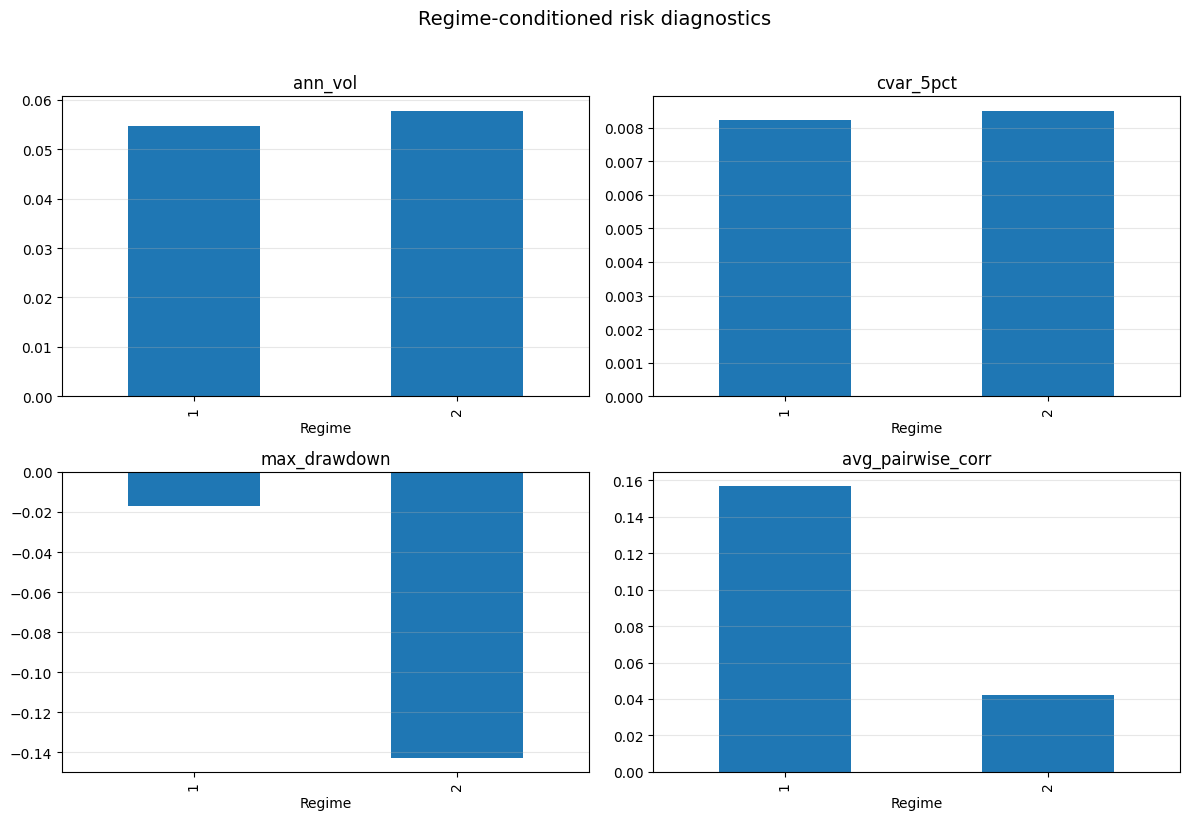

In [7]:
metrics_to_plot = [
    "ann_vol",
    "cvar_5pct",
    "max_drawdown",
    "avg_pairwise_corr",
]

plot_summary = risk_summary.set_index("regime")[metrics_to_plot]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8),
)

axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    plot_summary[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("Regime")
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Regime-conditioned risk diagnostics", y=1.02, fontsize=14)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_regime_risk_bars.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visual diagnostic — return distributions by regime

Distribution plots help avoid relying only on summary statistics.

The expected pattern is not necessarily higher average return in calm regimes. The more important question is whether adverse tails become more severe in higher-stress regimes.

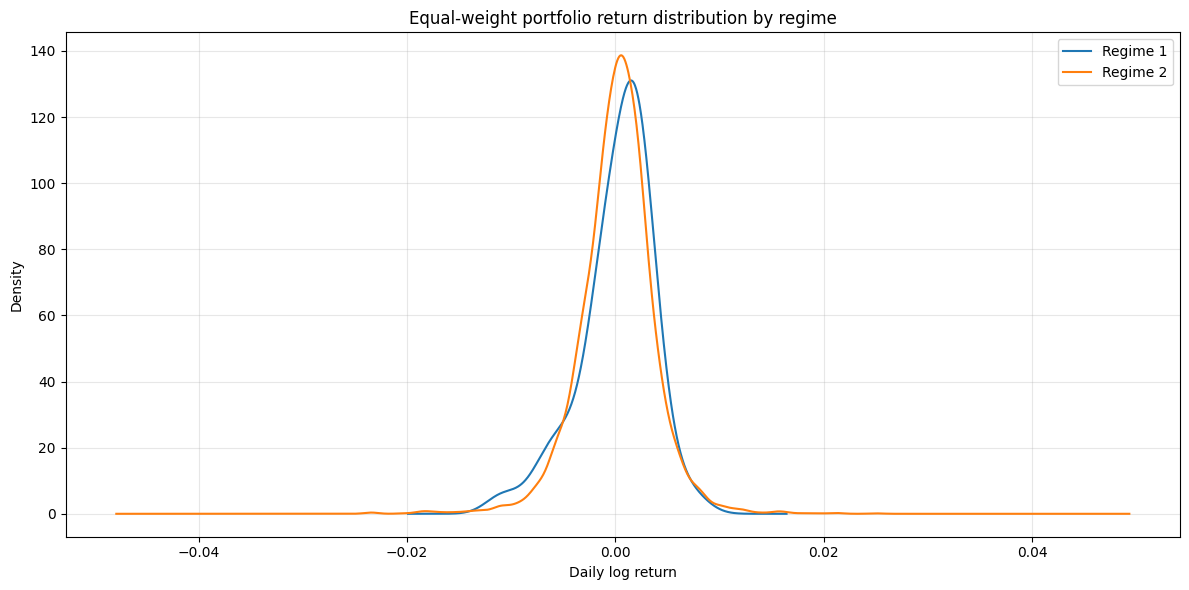

In [8]:
dist_df = pd.concat(
    [
        equal_weight_portfolio_returns.rename("portfolio_return"),
        regimes_aligned.rename("regime"),
    ],
    axis=1,
).dropna()

regime_values = sorted(dist_df["regime"].unique())

fig, ax = plt.subplots(figsize=(12, 6))

for regime in regime_values:
    sample = dist_df.loc[dist_df["regime"] == regime, "portfolio_return"]
    sample.plot(kind="kde", ax=ax, linewidth=1.5, label=f"Regime {regime}")

ax.set_title("Equal-weight portfolio return distribution by regime")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Density")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_regime_return_distributions.png", dpi=150)
plt.show()

## 7. Visual diagnostic — correlation heatmaps

The heatmaps show whether cross-asset dependence changes across regimes.

This is important because a portfolio can become fragile not only because individual assets become more volatile, but also because assets become more correlated.

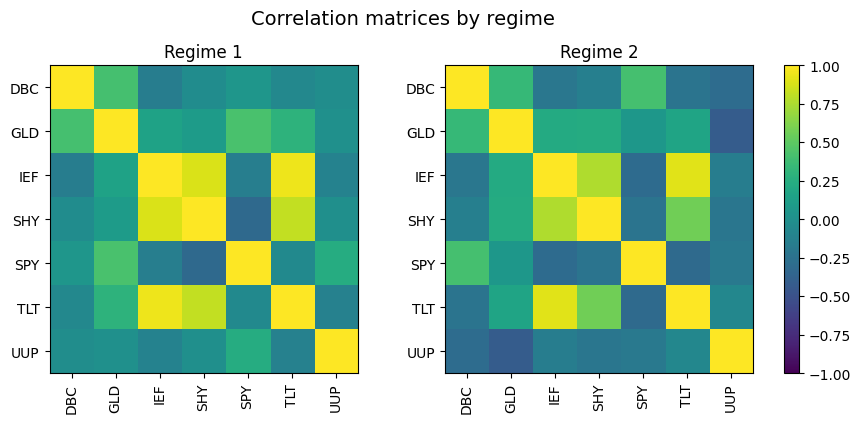

In [9]:
n_regimes = len(correlations)
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_regimes,
    figsize=(5 * n_regimes, 4),
    squeeze=False,
)

axes = axes.ravel()

for ax, regime in zip(axes, sorted(correlations)):
    corr = correlations[regime]
    im = ax.imshow(corr.values, vmin=-1, vmax=1)
    ax.set_title(f"Regime {regime}")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.index)))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)

fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.04)
fig.suptitle("Correlation matrices by regime", y=1.02, fontsize=14)
fig.savefig(FIGURE_DIR / "03_regime_correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Export risk diagnostics

The downstream allocation notebook will use these diagnostics to justify the risk-control design.

The exported long-format covariance and correlation files are easier to inspect and version than nested Python objects.

In [10]:
risk_summary.to_csv(DATA_DIR / "regime_risk_summary.csv", index=False)

corr_long = []
for regime, matrix in correlations.items():
    tmp = matrix.stack().rename("correlation").reset_index()
    tmp.columns = ["asset_i", "asset_j", "correlation"]
    tmp["regime"] = regime
    corr_long.append(tmp)

cov_long = []
for regime, matrix in covariances.items():
    tmp = matrix.stack().rename("covariance").reset_index()
    tmp.columns = ["asset_i", "asset_j", "covariance"]
    tmp["regime"] = regime
    cov_long.append(tmp)

corr_long = pd.concat(corr_long, ignore_index=True)
cov_long = pd.concat(cov_long, ignore_index=True)

corr_long.to_csv(DATA_DIR / "regime_correlation_long.csv", index=False)
cov_long.to_csv(DATA_DIR / "regime_covariance_long.csv", index=False)

print("Saved:")
print(DATA_DIR / "regime_risk_summary.csv")
print(DATA_DIR / "regime_correlation_long.csv")
print(DATA_DIR / "regime_covariance_long.csv")

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_risk_summary.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_correlation_long.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/regime_covariance_long.csv


## 9. Notebook takeaway

This notebook checks whether the detected regimes correspond to different risk environments.

A useful regime model should show differences in:

- realized volatility,
- downside tail risk,
- maximum drawdown,
- cross-asset correlation.

The next notebook uses these diagnostics to compare constant-risk allocation against regime-aware risk-budget allocation. The goal remains risk control and robustness, not claiming persistent alpha.